In [54]:
# ============================================================
# TELECOM CUSTOMER CHURN PREDICTION
# Descriptive + Diagnostic + Predictive Analytics
# ============================================================


# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

Step 1: Import Required Libraries

In this step, we import the Python libraries required for data manipulation, visualization, preprocessing, machine learning, and model evaluation.

The major libraries used are:

NumPy – Numerical computations
Pandas – Data manipulation and analysis
Matplotlib – Data visualization
Seaborn – Statistical visualization
Scikit-learn – Machine learning and model evaluation

In [55]:
# ============================================================
# STEP 2: LOAD THE DATASET
# ============================================================

file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])

print("\nFirst 5 Records:")
display(df.head())

DATASET LOADED SUCCESSFULLY
Number of Rows    : 7043
Number of Columns : 21

First 5 Records:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Step 2: Load the Dataset

In this step, the Telecom Customer Churn CSV file is loaded into a Pandas DataFrame.

The dataset contains information about customers, their subscribed services, contract details, charges, tenure, and whether they churned.

The DataFrame will be used for all subsequent descriptive, diagnostic, and predictive analyses.

In [56]:
# ============================================================
# STEP 3: BASIC DATA UNDERSTANDING
# ============================================================

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


DATASET INFORMATION

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Dataset Information:
<cl

Step 3: Basic Data Understanding

Before performing any analysis, it is important to understand the structure and characteristics of the dataset.

This step examines:

Number of rows and columns
Column names
Data types
Dataset information
Missing values
Duplicate records

This helps identify potential data-quality issues before performing further analysis.

In [57]:
# ============================================================
# STEP 4: DATA CLEANING
# ============================================================

# Remove unnecessary customer ID
df = df.drop("customerID", axis=1)

# Convert TotalCharges to numeric
# Some records contain blank spaces
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values created by conversion
print("\nMissing values after converting TotalCharges:")
print(df.isnull().sum())

# Fill missing TotalCharges using median
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())


Missing values after converting TotalCharges:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Missing values after cleaning:
0


Step 4: Data Cleaning

Data cleaning is performed to prepare the dataset for analysis and machine learning.

The following operations are performed:

Remove the customerID column because it is an identifier and does not provide useful predictive information.
Convert TotalCharges from text to numeric format.
Handle missing values in TotalCharges.
Verify that the dataset does not contain remaining missing values.

Clean data is essential for producing reliable analytical and machine learning results.

In [58]:
# ============================================================
# STEP 5: TARGET VARIABLE DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("TARGET VARIABLE - CHURN")
print("=" * 70)

print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(
    df["Churn"].value_counts(normalize=True) * 100
)


TARGET VARIABLE - CHURN
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


Step 5: Target Variable Distribution

The target variable in this project is Churn.

It contains two possible values:

Yes – The customer has churned.
No – The customer has remained with the company.

The distribution of these values is examined to understand the proportion of customers who have churned versus those who have been retained.

The overall churn rate is an important business metric because it indicates the scale of the customer-retention problem.

In [59]:
# ============================================================
# DESCRIPTIVE ANALYTICS
# ============================================================

print("\n\n" + "=" * 70)
print("DESCRIPTIVE ANALYTICS")
print("=" * 70)


# ============================================================
# STEP 6: NUMERICAL SUMMARY
# ============================================================

print("\nNumerical Summary Statistics:")

display(
    df.describe()
)




DESCRIPTIVE ANALYTICS

Numerical Summary Statistics:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


Step 6: Numerical Summary Statistics

Descriptive statistics are calculated for numerical variables in the dataset.

Important statistics include:

Count
Mean
Standard deviation
Minimum
Maximum
25th percentile
Median
75th percentile

These statistics provide an initial understanding of variables such as:

Customer tenure
Monthly charges
Total charges

In [60]:
# ============================================================
# STEP 7: CATEGORICAL SUMMARY
# ============================================================

categorical_columns = df.select_dtypes(
    include="object"
).columns

print("\nCategorical Variables:")

for column in categorical_columns:
    print("\n------------------------------------------")
    print(column)
    print("------------------------------------------")
    print(df[column].value_counts())



Categorical Variables:

------------------------------------------
gender
------------------------------------------
gender
Male      3555
Female    3488
Name: count, dtype: int64

------------------------------------------
Partner
------------------------------------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64

------------------------------------------
Dependents
------------------------------------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

------------------------------------------
PhoneService
------------------------------------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

------------------------------------------
MultipleLines
------------------------------------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

------------------------------------------
InternetService
------------------------------------------
InternetService
Fiber opt

Step 7: Categorical Summary

Categorical variables are analyzed to understand the different customer segments present in the dataset.

Examples include:

Gender
Contract type
Internet service
Payment method
Partner status
Dependents
Phone service

The frequency of each category is calculated to understand the composition of the customer base.

In [61]:
# ============================================================
# STEP 8: OVERALL CHURN RATE
# ============================================================

churn_count = df["Churn"].value_counts()

print("\nTotal Customers :", len(df))
print("Customers Churned :", churn_count["Yes"])
print("Customers Retained:", churn_count["No"])

churn_rate = (
    df["Churn"].value_counts(normalize=True)["Yes"] * 100
)

print(f"Overall Churn Rate: {churn_rate:.2f}%")


Total Customers : 7043
Customers Churned : 1869
Customers Retained: 5174
Overall Churn Rate: 26.54%


Step 8: Overall Churn Rate

The overall customer churn rate is calculated in this step.

The churn rate is calculated using the formula:

[
\text{Churn Rate} =
\frac{\text{Number of Churned Customers}}
{\text{Total Number of Customers}}
\times 100
]

This metric provides a high-level view of customer retention performance.

A higher churn rate indicates a greater customer-retention challenge for the telecom company.

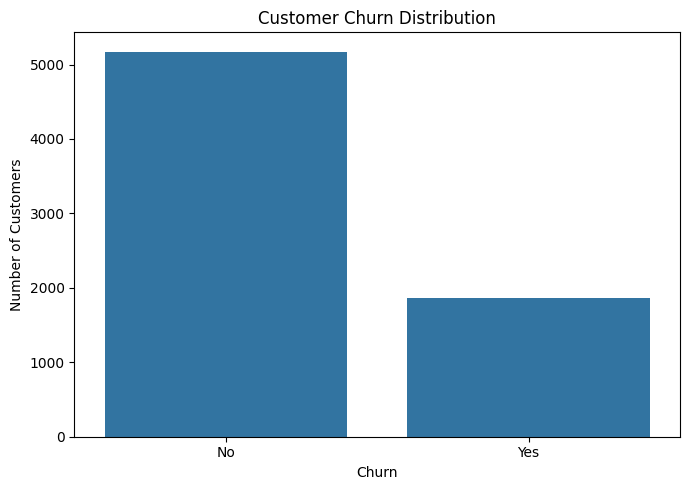

In [62]:
# ============================================================
# STEP 9: DESCRIPTIVE VISUALIZATION
# CHURN DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Step 9: Churn Distribution Visualization

A count plot is created to visualize the number of customers who churned and those who did not churn.

This visualization makes it easier to compare:

Customers who stayed
Customers who left

The chart also helps identify whether the target variable is balanced or imbalanced.

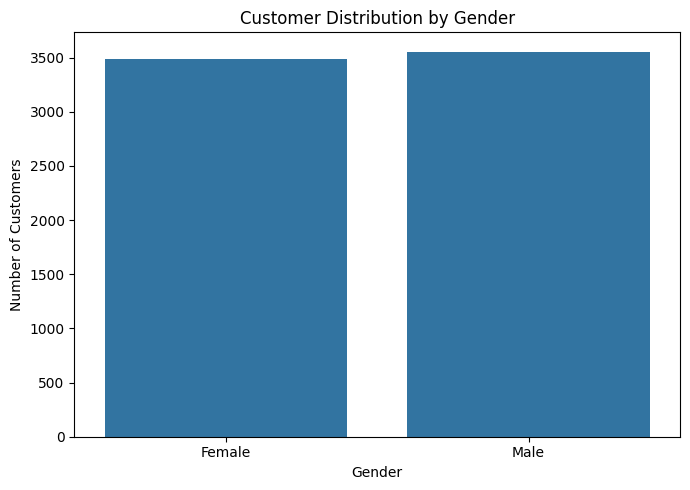

In [63]:
# ============================================================
# STEP 10: GENDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


Step 10: Gender Distribution

This step visualizes the distribution of customers by gender.

The purpose is to understand the demographic composition of the customer base.

Gender distribution can subsequently be compared with churn behavior to determine whether there are noticeable differences between customer groups.

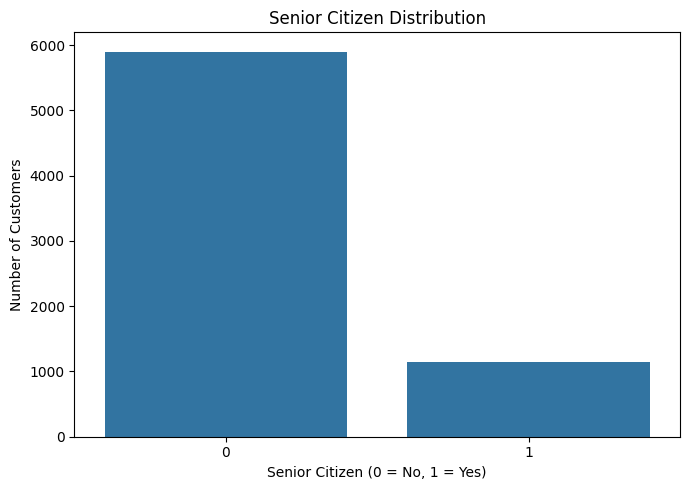

In [64]:
# ============================================================
# STEP 11: SENIOR CITIZEN DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="SeniorCitizen"
)

plt.title("Senior Citizen Distribution")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


Step 11: Senior Citizen Distribution

This visualization examines the distribution of senior and non-senior customers.

The SeniorCitizen variable uses:

0 – Customer is not a senior citizen
1 – Customer is a senior citizen

Understanding this distribution is useful when investigating whether customer age characteristics are associated with churn.

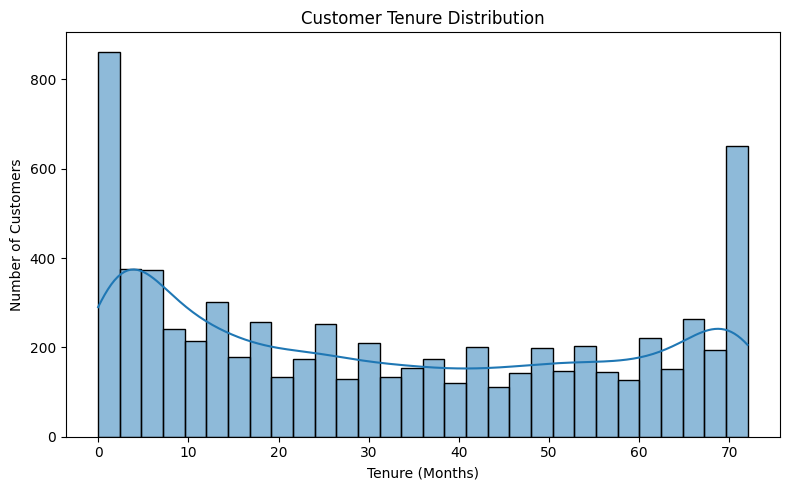

In [65]:
# ============================================================
# STEP 12: TENURE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Step 12: Customer Tenure Distribution

Customer tenure represents the number of months a customer has remained with the telecom company.

A histogram is used to examine the distribution of customer tenure.

This analysis helps identify whether the customer base consists primarily of:

New customers
Medium-term customers
Long-term customers

Tenure is also an important variable for understanding customer loyalty and churn behavior.

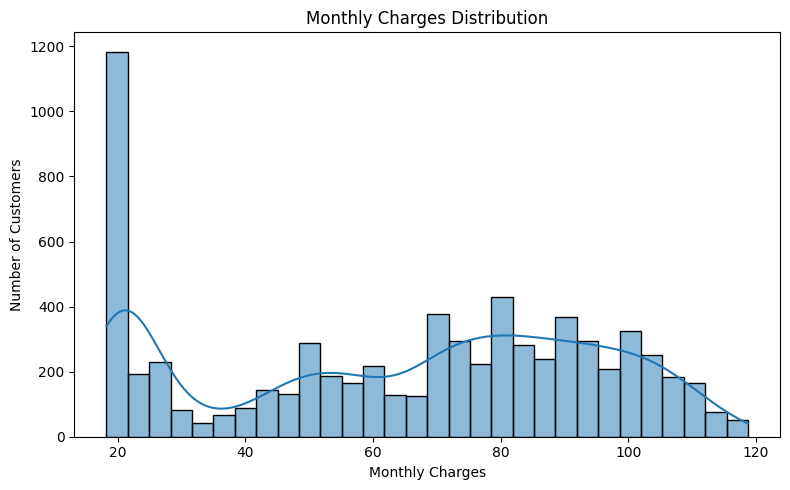

In [66]:
# ============================================================
# STEP 13: MONTHLY CHARGES DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Step 13: Monthly Charges Distribution

This step analyzes the distribution of monthly charges paid by customers.

A histogram with a density curve is used to understand the range and distribution of monthly charges.

The analysis helps determine whether customers with higher monthly charges may represent a potentially higher-risk segment.

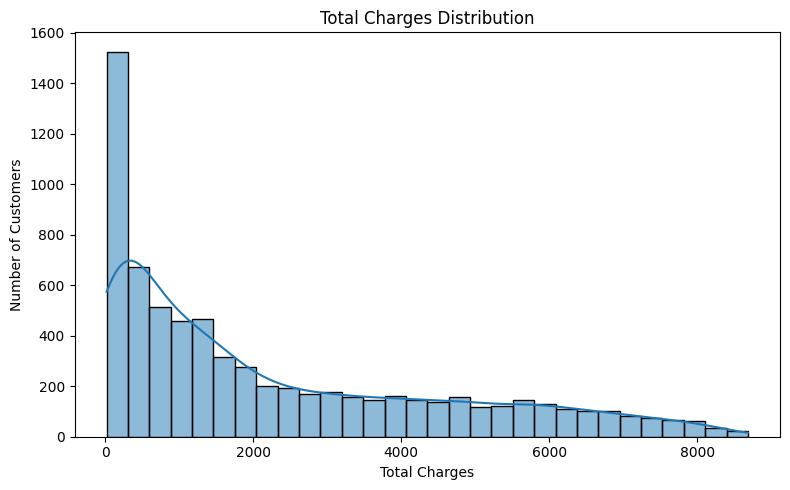

In [67]:
# ============================================================
# STEP 14: TOTAL CHARGES DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="TotalCharges",
    bins=30,
    kde=True
)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


Step 14: Total Charges Distribution

Total charges represent the cumulative amount charged to a customer during their relationship with the telecom company.

The distribution of total charges is visualized using a histogram.

This helps understand customer revenue contribution and provides another variable that can be investigated in relation to churn.



DIAGNOSTIC ANALYTICS

Diagnostic Analytics answers:

"WHY are customers churning?"

We compare Churn against important customer characteristics
such as contract, tenure, internet service, payment method,
monthly charges and senior citizen status.


Churn Percentage by Contract:


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


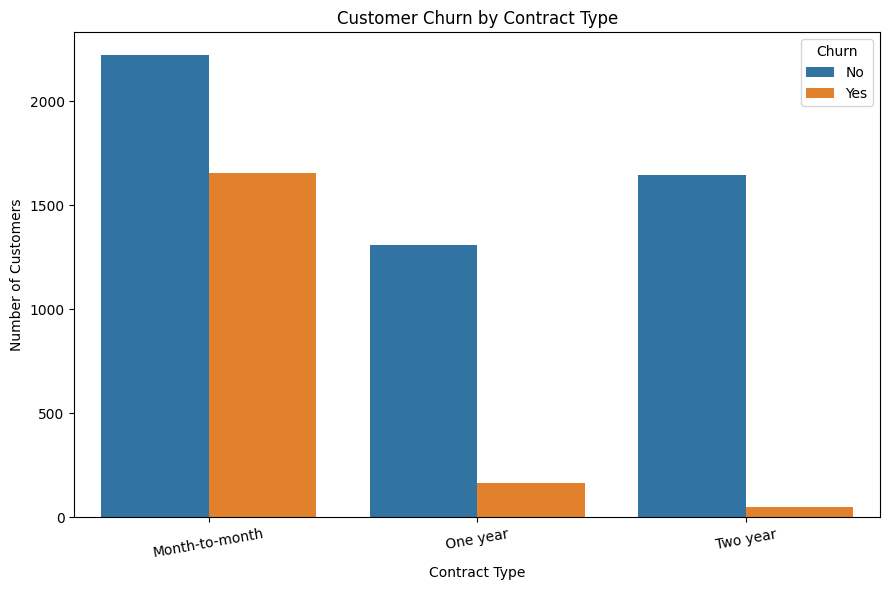

In [68]:
# ============================================================
# DIAGNOSTIC ANALYTICS
# ============================================================

print("\n\n" + "=" * 70)
print("DIAGNOSTIC ANALYTICS")
print("=" * 70)

print("""
Diagnostic Analytics answers:

"WHY are customers churning?"

We compare Churn against important customer characteristics
such as contract, tenure, internet service, payment method,
monthly charges and senior citizen status.
""")


# ============================================================
# STEP 15: CHURN BY CONTRACT
# ============================================================

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Percentage by Contract:")
display(contract_churn)


plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

Step 15: Churn by Contract Type

Contract type is analyzed against customer churn.

The major contract categories are:

Month-to-month
One year
Two year

The churn percentage for each contract type is calculated.

This diagnostic analysis helps answer:

Does the type of contract influence customer churn?

The results can help the business identify contract segments requiring stronger retention strategies.

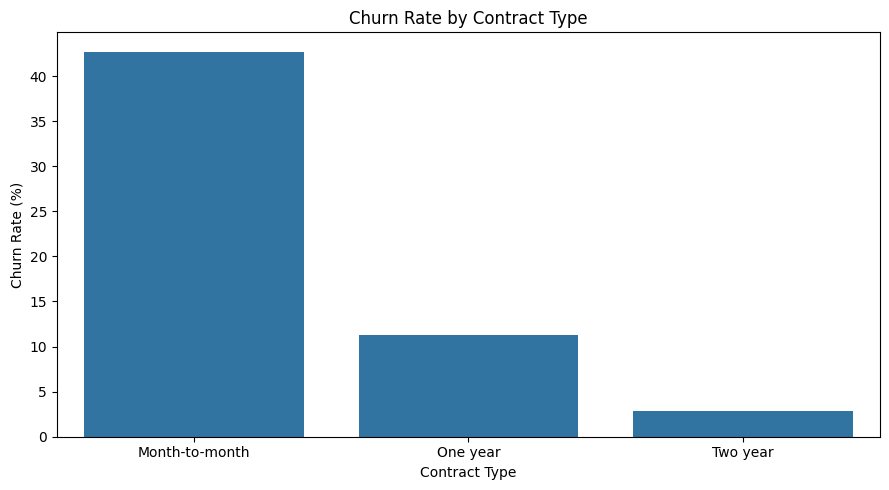

In [69]:
# ============================================================
# STEP 16: CHURN RATE BY CONTRACT
# ============================================================

contract_churn_plot = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=contract_churn_plot,
    x="Contract",
    y="ChurnRate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

Step 16: Churn Rate by Contract

A bar chart is created to compare the churn rate across different contract types.

The churn rate is calculated separately for each contract category.

This visualization provides a clearer comparison of customer-retention performance across contract groups.

Contract type can be particularly useful for identifying customers who have less long-term commitment to the company.


Churn Percentage by Internet Service:


Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


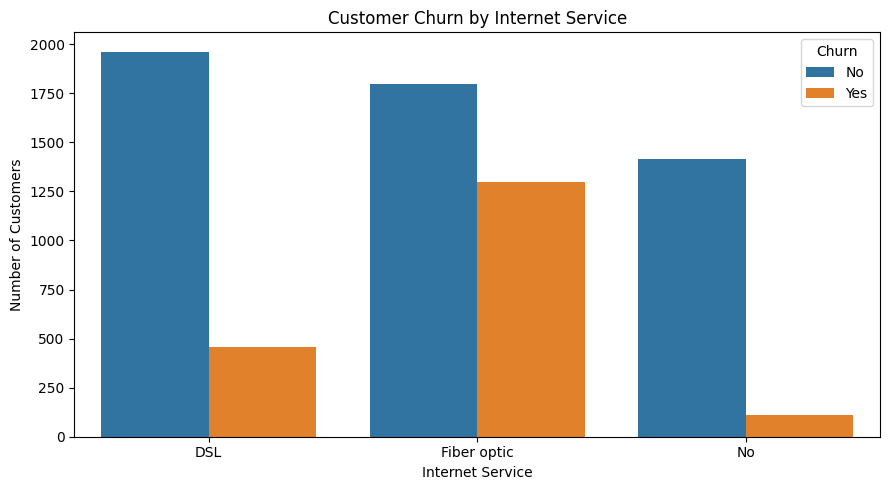

In [70]:
# ============================================================
# STEP 17: CHURN BY INTERNET SERVICE
# ============================================================

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Percentage by Internet Service:")
display(internet_churn)


plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Step 17: Churn by Internet Service

Customer churn is analyzed based on the type of internet service subscribed to by customers.

The major categories include:

DSL
Fiber optic
No internet service

The analysis compares churned and retained customers across these service categories.

This helps determine whether internet service type is associated with customer churn.


Churn Percentage by Payment Method:


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


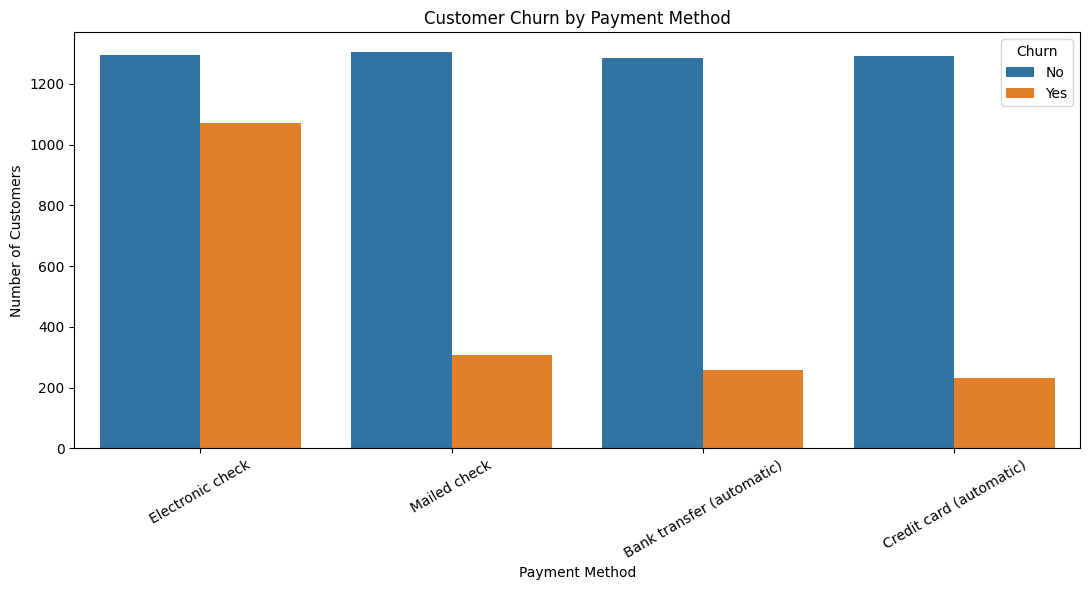

In [71]:
# ============================================================
# STEP 18: CHURN BY PAYMENT METHOD
# ============================================================

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Percentage by Payment Method:")
display(payment_churn)


plt.figure(figsize=(11, 6))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Step 18: Churn by Payment Method

Payment method is investigated as a potential factor associated with customer churn.

Customers are grouped according to their payment method, and their churn behavior is compared.

This analysis can help the company identify whether particular payment methods are associated with higher customer churn.


Churn Percentage by Senior Citizen Status:


Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


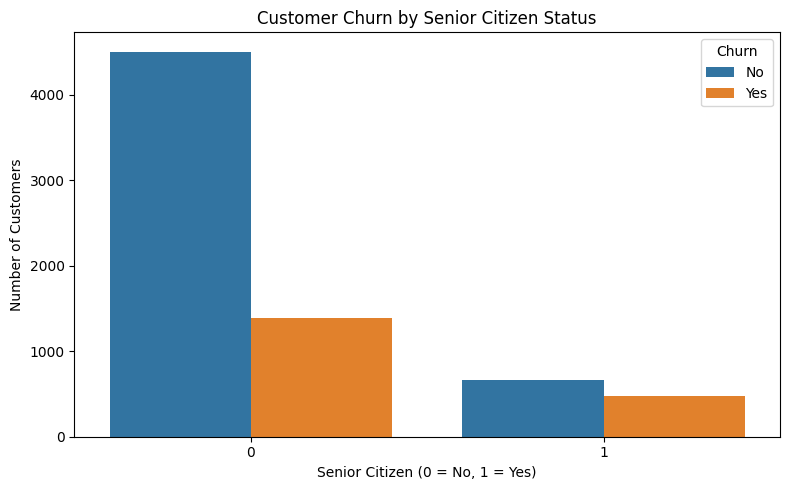

In [72]:
# ============================================================
# STEP 19: CHURN BY SENIOR CITIZEN
# ============================================================

senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Percentage by Senior Citizen Status:")
display(senior_churn)


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Step 19: Churn by Senior Citizen Status

Customer churn is compared between senior and non-senior customers.

The analysis examines whether senior citizens have a different churn pattern compared with other customers.

This is an example of diagnostic analytics because it investigates whether a customer characteristic may be associated with churn.

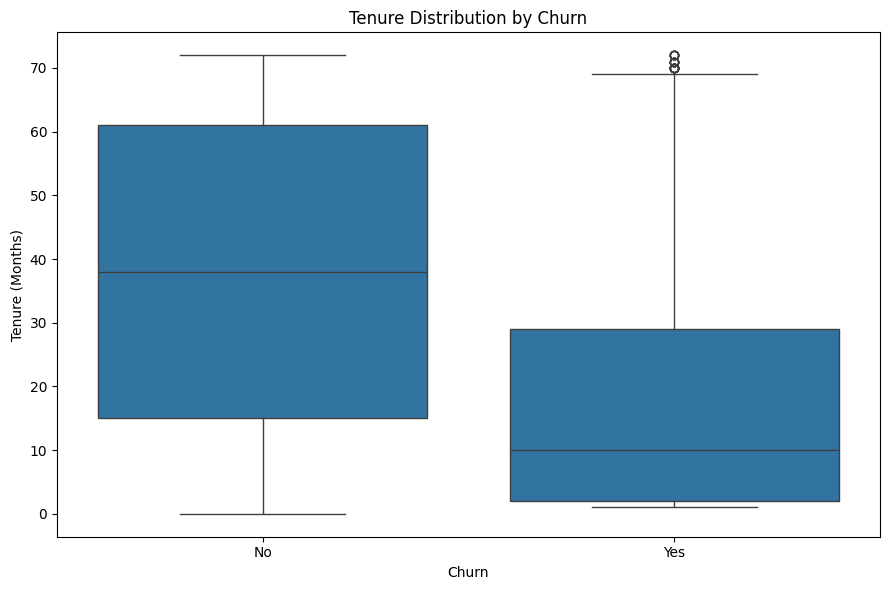

In [73]:
# ============================================================
# STEP 20: CHURN VS TENURE
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

Step 20: Churn vs Tenure

Customer tenure is compared between churned and retained customers using a box plot.

The box plot helps compare:

Median tenure
Spread of tenure
Possible outliers
Differences between churn groups

This analysis helps determine whether customers with shorter or longer relationships with the company are more likely to churn.

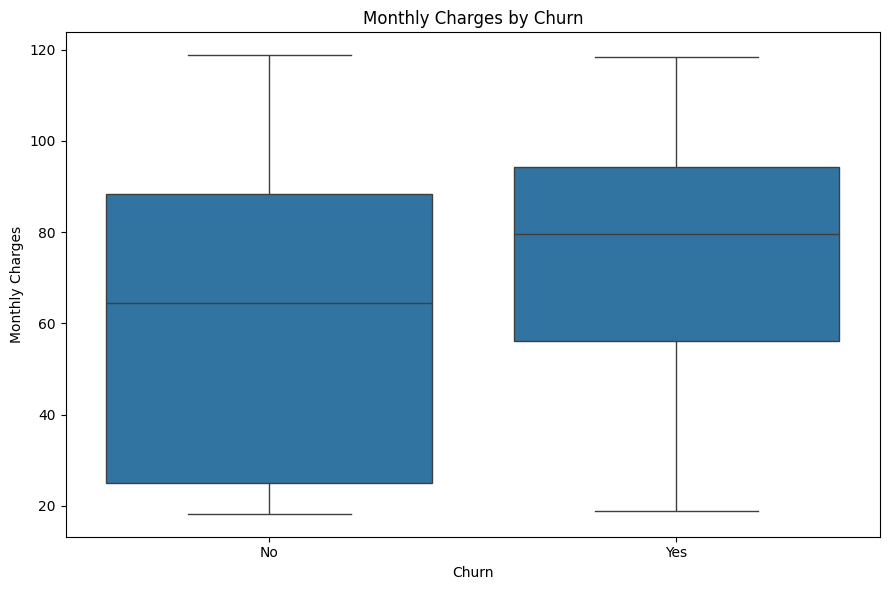

In [74]:
# ============================================================
# STEP 21: CHURN VS MONTHLY CHARGES
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

Step 21: Churn vs Monthly Charges

Monthly charges are compared between customers who churned and customers who remained.

A box plot is used to identify differences in the distribution of monthly charges.

This analysis helps determine whether customers paying higher monthly charges may have a greater likelihood of leaving the company.

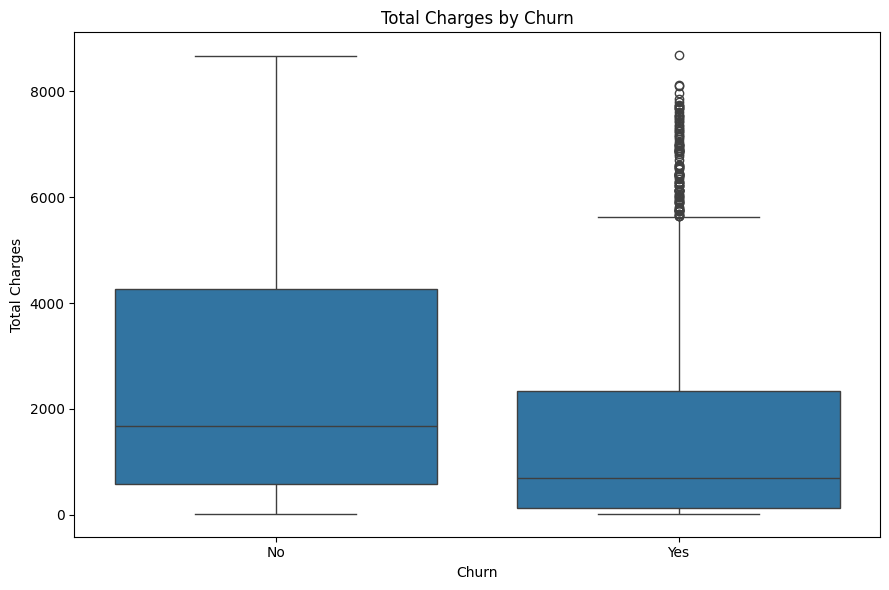

In [75]:
# ============================================================
# STEP 22: CHURN VS TOTAL CHARGES
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.tight_layout()
plt.show()

Step 22: Churn vs Total Charges

Total charges are compared across churned and retained customers.

A box plot is used to visualize the distribution of total charges for both groups.

Because total charges are influenced by both tenure and monthly charges, this variable provides information about the customer's overall financial relationship with the company.


Correlation Matrix:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102652
tenure,0.016567,1.000000,0.247900,0.825464
MonthlyCharges,0.220173,0.247900,1.000000,0.650864
TotalCharges,0.102652,0.825464,0.650864,1.000000


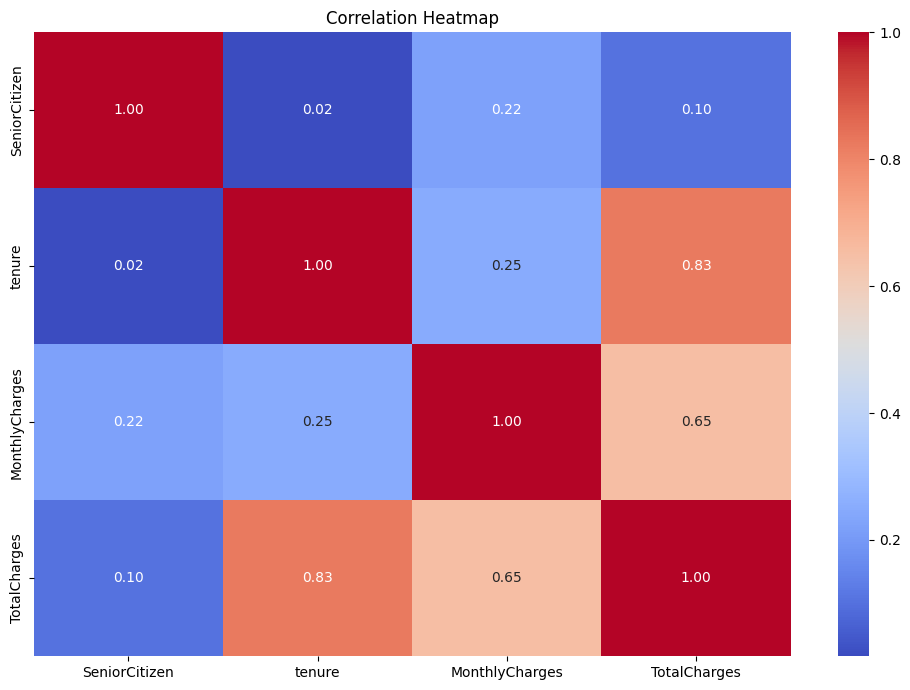

In [76]:
# ============================================================
# STEP 23: CORRELATION ANALYSIS
# ============================================================

numeric_columns = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_columns.corr()

print("\nCorrelation Matrix:")
display(correlation_matrix)


plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

Step 23: Correlation Analysis

Correlation analysis is performed on numerical variables.

A correlation matrix is generated to identify relationships between numerical variables.

The correlation coefficient ranges from:

[
-1 \leq r \leq 1
]

where:

+1 indicates a strong positive relationship.
-1 indicates a strong negative relationship.
0 indicates little or no linear relationship.

A heatmap is used to visualize the correlation matrix.


Churn Rate by Tenure Group:


,TenureGroup,ChurnRate
0,0-12 Months,47.678161
1,13-24 Months,28.710938
2,25-48 Months,20.388959
3,49-60 Months,14.423077
4,60+ Months,6.609808


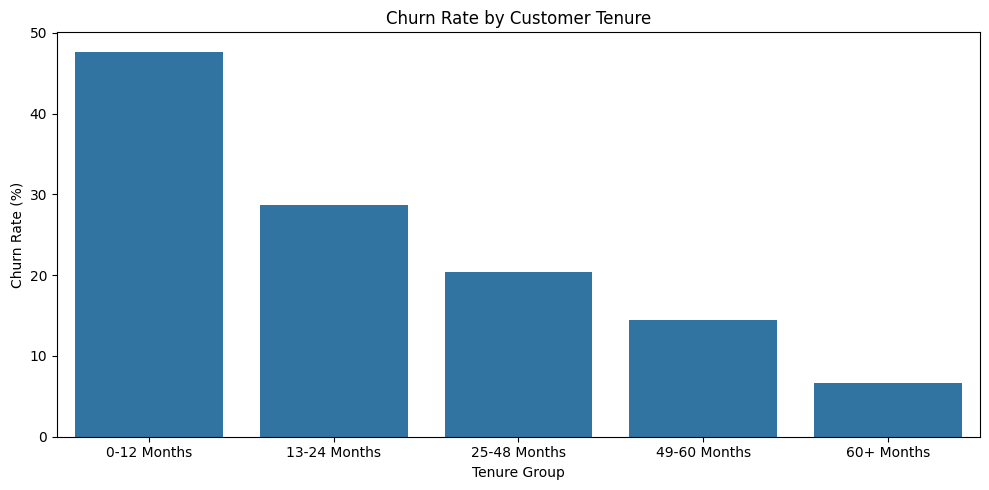

In [77]:
# ============================================================
# STEP 24: CHURN RATE BY TENURE GROUP
# ============================================================

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 60, 100],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-60 Months",
        "60+ Months"
    ]
)

tenure_churn = (
    df.groupby("TenureGroup", observed=False)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

print("\nChurn Rate by Tenure Group:")
display(tenure_churn)


plt.figure(figsize=(10, 5))

sns.barplot(
    data=tenure_churn,
    x="TenureGroup",
    y="ChurnRate"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

Step 24: Churn Rate by Tenure Group

Customers are divided into different tenure groups:

0–12 months
13–24 months
25–48 months
49–60 months
60+ months

The churn rate is then calculated for each group.

This provides a more business-friendly view of the relationship between customer loyalty and churn.

The results can help identify whether newly acquired customers require additional retention efforts.

In [78]:
# ============================================================
# PREDICTIVE ANALYTICS
# ============================================================

print("\n\n" + "=" * 70)
print("PREDICTIVE ANALYTICS")
print("=" * 70)

print("""
Predictive Analytics answers:

"Which customers are likely to churn?"

We will train machine learning models to predict
whether a customer will churn.

Models:
1. Logistic Regression
2. Random Forest Classifier
""")


# ============================================================
# STEP 25: PREPARE DATA FOR MACHINE LEARNING
# ============================================================

# Remove helper column
df_model = df.drop("TenureGroup", axis=1)

# Convert target variable
df_model["Churn"] = df_model["Churn"].map({
    "No": 0,
    "Yes": 1
})


# Separate features and target
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]


# Identify categorical and numerical columns
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)



PREDICTIVE ANALYTICS

Predictive Analytics answers:

"Which customers are likely to churn?"

We will train machine learning models to predict
whether a customer will churn.

Models:
1. Logistic Regression
2. Random Forest Classifier


Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Step 25: Prepare Data for Machine Learning

The dataset is prepared for predictive modeling.

The following steps are performed:

Remove the temporary tenure-group variable.
Convert the Churn target variable into numerical values.
Separate independent variables X from the target variable y.
Identify numerical features.
Identify categorical features.

The target variable is encoded as:

0 = No churn
1 = Churn

In [79]:
# ============================================================
# STEP 26: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Records:", X_train.shape[0])
print("Testing Records :", X_test.shape[0])


Training Records: 5634
Testing Records : 1409


Step 26: Train-Test Split

The dataset is divided into training and testing datasets.

The training dataset is used to train the machine learning models.

The testing dataset is used to evaluate how well the trained models perform on previously unseen data.

An 80:20 split is used:

80% – Training data
20% – Testing data

Stratification is used to preserve the churn distribution in both datasets.

In [80]:
# ============================================================
# STEP 27: PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

Step 27: Data Preprocessing

Machine learning algorithms require the input data to be represented in an appropriate numerical format.

Two preprocessing techniques are applied:

Numerical Features

Numerical variables are standardized using StandardScaler.

Categorical Features

Categorical variables are converted into numerical representations using OneHotEncoder.

A ColumnTransformer combines both preprocessing operations into a single preprocessing pipeline.

This ensures consistent preprocessing during both training and prediction.

In [81]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)


# Train model
logistic_model.fit(
    X_train,
    y_train
)


# Make predictions
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# STEP 28: LOGISTIC REGRESSION EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 70)

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")
print(f"ROC-AUC   : {lr_auc:.4f}")


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)


LOGISTIC REGRESSION RESULTS
Accuracy  : 0.8055
Precision : 0.6572
Recall    : 0.5588
F1 Score  : 0.6040
ROC-AUC   : 0.8419

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Step 28: Logistic Regression Evaluation

Logistic Regression is used as one of the classification models.

It predicts the probability that a customer will churn.

The model is evaluated using:

Accuracy
Precision
Recall
F1 Score
ROC-AUC

For churn prediction, recall is particularly important because failing to identify a customer who is actually going to churn can result in a lost customer.

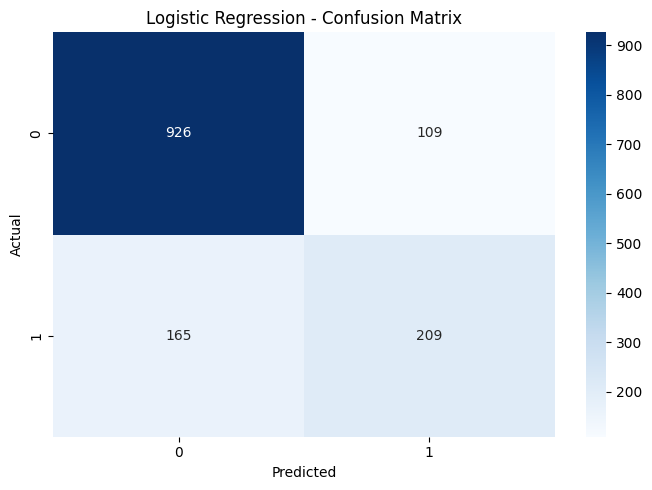

In [82]:
# ============================================================
# STEP 29: LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


Step 29: Logistic Regression Confusion Matrix

A confusion matrix is created to evaluate Logistic Regression predictions.

The matrix contains four outcomes:

True Negative (TN) – Correctly predicted retained customer
False Positive (FP) – Predicted churn but customer stayed
False Negative (FN) – Predicted retained but customer churned
True Positive (TP) – Correctly predicted churned customer

The confusion matrix provides a detailed view of classification performance.

In [83]:
# ============================================================
# MODEL 2: RANDOM FOREST
# ============================================================

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)


# Train model
random_forest_model.fit(
    X_train,
    y_train
)


# Predictions
y_pred_rf = random_forest_model.predict(
    X_test
)

y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]

# ============================================================
# STEP 30: RANDOM FOREST EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("RANDOM FOREST RESULTS")
print("=" * 70)

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)


RANDOM FOREST RESULTS
Accuracy  : 0.7821
Precision : 0.6175
Recall    : 0.4706
F1 Score  : 0.5341
ROC-AUC   : 0.8217

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



Step 30: Random Forest Evaluation

Random Forest Classifier is used as a second predictive model.

Random Forest combines multiple decision trees to improve predictive performance and reduce overfitting.

The model is evaluated using:

Accuracy
Precision
Recall
F1 Score
ROC-AUC

The results are later compared with Logistic Regression.

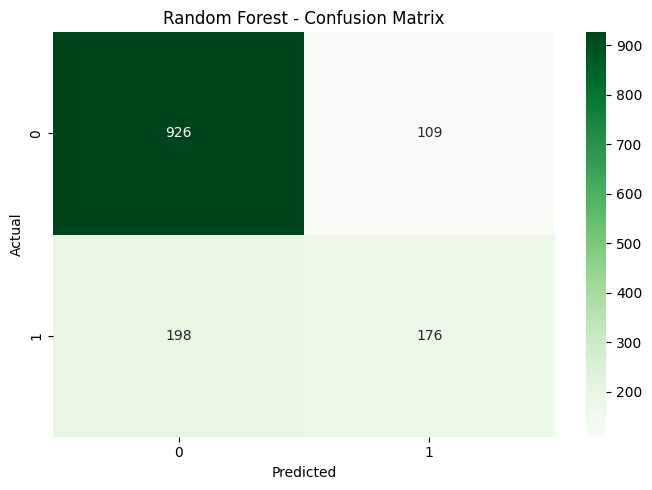

In [84]:
# ============================================================
# STEP 31: RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

Step 31: Random Forest Confusion Matrix

A confusion matrix is generated for the Random Forest model.

This allows us to examine how accurately the model identifies:

Customers who stay
Customers who churn

The confusion matrix is especially useful for evaluating the number of actual churners that the model successfully identifies.

In [85]:
# ============================================================
# STEP 32: MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc
    ]
})

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(model_comparison)


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841874
1,Random Forest,0.782115,0.617544,0.470588,0.534143,0.821664


Step 32: Model Comparison

The performance of Logistic Regression and Random Forest is compared using a common evaluation table.

The following metrics are compared:

Accuracy
Precision
Recall
F1 Score
ROC-AUC

The comparison helps determine which model provides better predictive performance for this customer churn problem.

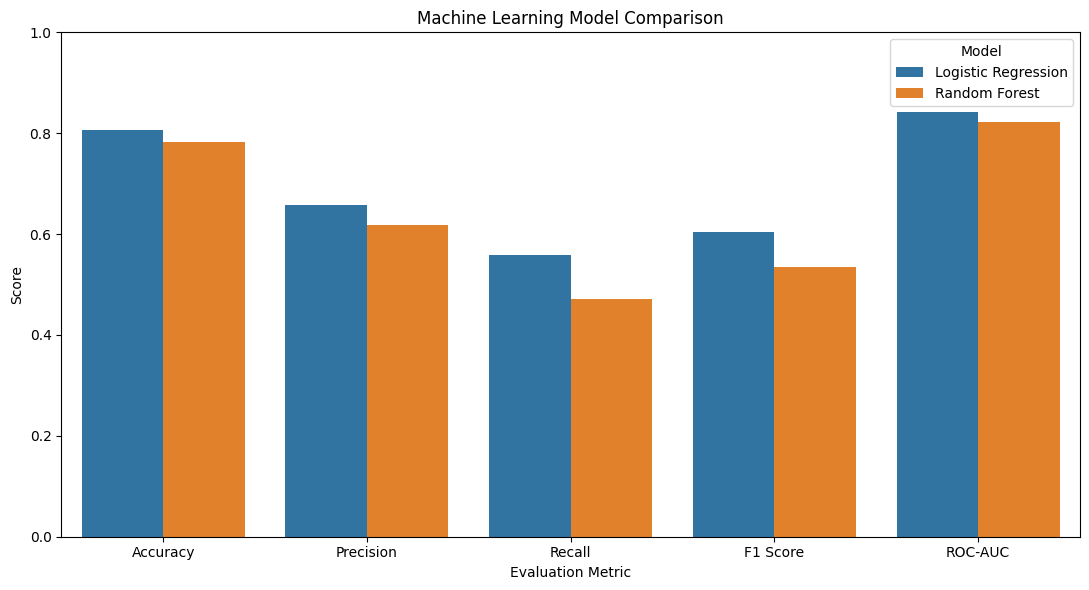

In [86]:
# ============================================================
# STEP 33: MODEL COMPARISON VISUALIZATION
# ============================================================

comparison_melted = model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

Step 33: Model Comparison Visualization

A bar chart is created to visually compare the performance of the two machine learning models.

The chart displays the different evaluation metrics for:

Logistic Regression
Random Forest

A higher value generally indicates better performance, although the importance of each metric depends on the business objective.

For customer churn, recall and ROC-AUC can be particularly useful in addition to accuracy.

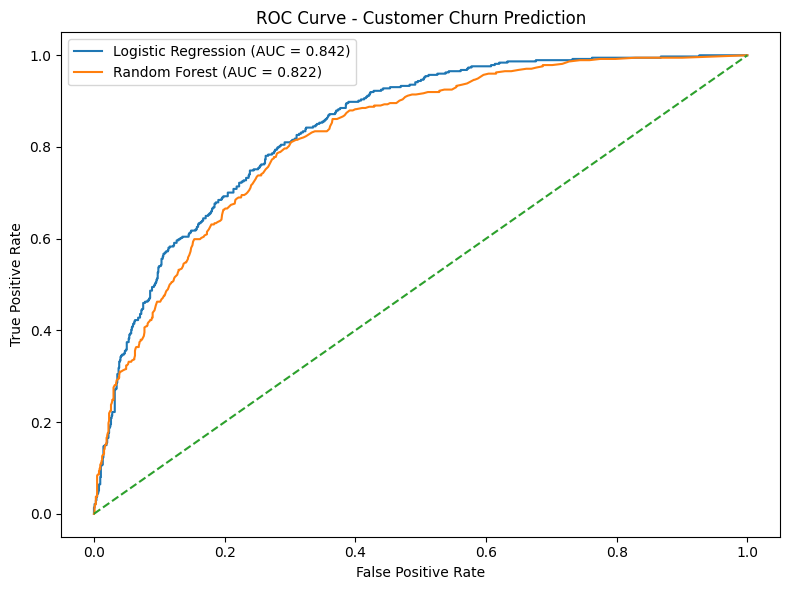

In [87]:
# ============================================================
# STEP 34: ROC CURVE
# ============================================================

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)


plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve - Customer Churn Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.tight_layout()
plt.show()

Step 34: ROC Curve

The Receiver Operating Characteristic (ROC) curve is used to evaluate classification performance across different probability thresholds.

The ROC curve plots:

True Positive Rate
False Positive Rate

The Area Under the Curve (AUC) summarizes the model's ability to distinguish between churned and retained customers.

A larger AUC generally indicates stronger classification performance.

Both Logistic Regression and Random Forest are compared using their ROC curves.

In [88]:
# ============================================================
# STEP 35: RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Get trained preprocessing object
rf_preprocessor = (
    random_forest_model
    .named_steps["preprocessor"]
)

rf_classifier = (
    random_forest_model
    .named_steps["classifier"]
)


# Get transformed feature names
feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)


# Get importance values
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})


# Sort
feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)


print("\n" + "=" * 70)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 70)

display(
    feature_importance.head(20)
)


TOP 20 IMPORTANT FEATURES


,Feature,Importance
3,num__TotalCharges,0.142162
1,num__tenure,0.130349
2,num__MonthlyCharges,0.122673
36,cat__Contract_Month-to-month,0.072880
18,cat__OnlineSecurity_No,0.038525
38,cat__Contract_Two year,0.035327
27,cat__TechSupport_No,0.032809
43,cat__PaymentMethod_Electronic check,0.029003
16,cat__InternetService_Fiber optic,0.027833
21,cat__OnlineBackup_No,0.017058


Step 35: Random Forest Feature Importance

Random Forest provides feature-importance scores that indicate which transformed features contribute most to the model's predictions.

The feature importance values are extracted from the trained Random Forest model.

The features are then sorted from highest to lowest importance.

This helps identify the customer characteristics that are most useful for predicting churn.

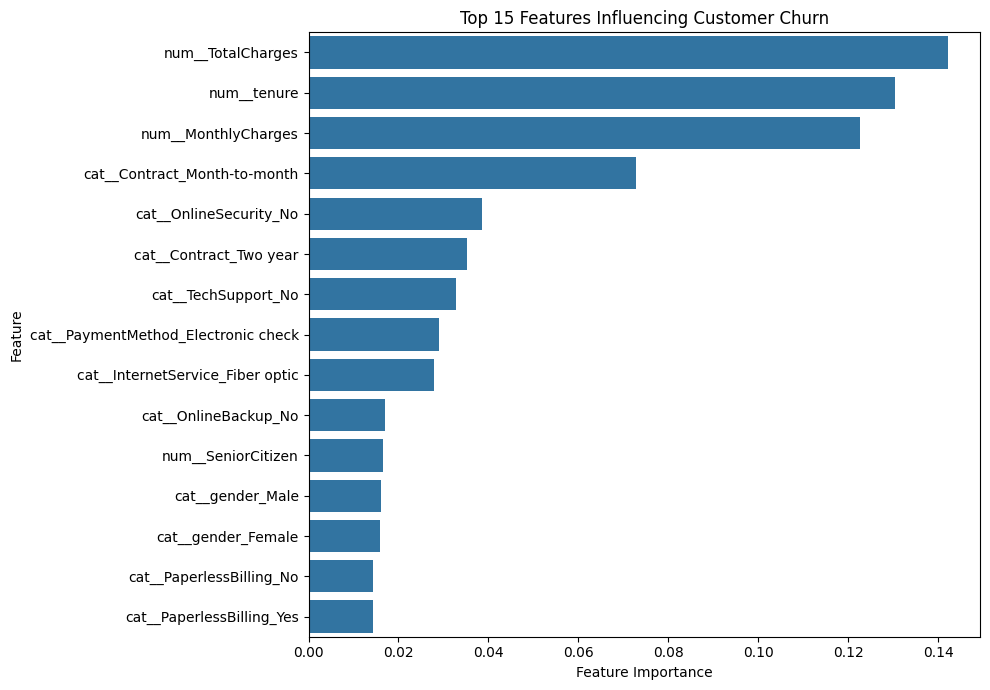

In [89]:
# ============================================================
# STEP 36: FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features Influencing Customer Churn"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Step 36: Feature Importance Visualization

The top 15 features identified by Random Forest are visualized using a horizontal bar chart.

This visualization helps business stakeholders understand which customer characteristics have the strongest influence on the model's churn predictions.

Feature importance can support the development of targeted customer-retention strategies.

In [90]:
# ============================================================
# STEP 37: PREDICT CHURN PROBABILITY
# ============================================================

# Create prediction output
prediction_results = X_test.copy()

prediction_results["Actual_Churn"] = y_test.values

prediction_results["Predicted_Churn"] = y_pred_rf

prediction_results["Churn_Probability"] = y_prob_rf

prediction_results["Churn_Prediction"] = np.where(
    prediction_results["Churn_Probability"] >= 0.5,
    "High Risk",
    "Low Risk"
)


# Sort by highest churn probability
prediction_results = prediction_results.sort_values(
    "Churn_Probability",
    ascending=False
)


print("\n" + "=" * 70)
print("CUSTOMERS WITH HIGHEST CHURN RISK")
print("=" * 70)

display(
    prediction_results[
        [
            "tenure",
            "Contract",
            "MonthlyCharges",
            "TotalCharges",
            "Churn_Probability",
            "Churn_Prediction"
        ]
    ].head(20)
)


CUSTOMERS WITH HIGHEST CHURN RISK


,tenure,Contract,MonthlyCharges,TotalCharges,Churn_Probability,Churn_Prediction
2927,1,Month-to-month,69.90,69.90,1.000000,High Risk
1731,1,Month-to-month,69.60,69.60,1.000000,High Risk
1739,1,Month-to-month,69.90,69.90,1.000000,High Risk
6623,1,Month-to-month,76.45,76.45,0.993333,High Risk
809,1,Month-to-month,69.55,69.55,0.993333,High Risk
2194,1,Month-to-month,79.50,79.50,0.993333,High Risk
1144,1,Month-to-month,35.55,35.55,0.990000,High Risk
1081,46,Month-to-month,98.85,4564.90,0.960000,High Risk
4585,1,Month-to-month,85.05,85.05,0.960000,High Risk
6633,1,Month-to-month,74.50,74.50,0.956667,High Risk


Step 37: Predict Churn Probability

The trained Random Forest model is used to predict churn probabilities for customers in the test dataset.

Each customer receives:

Actual churn status
Predicted churn status
Churn probability
Churn risk classification

Customers with higher predicted churn probabilities can be prioritized for retention campaigns.


Customer Churn Risk Distribution:


,RiskLevel,CustomerCount
0,Low Risk,1120
1,High Risk,289


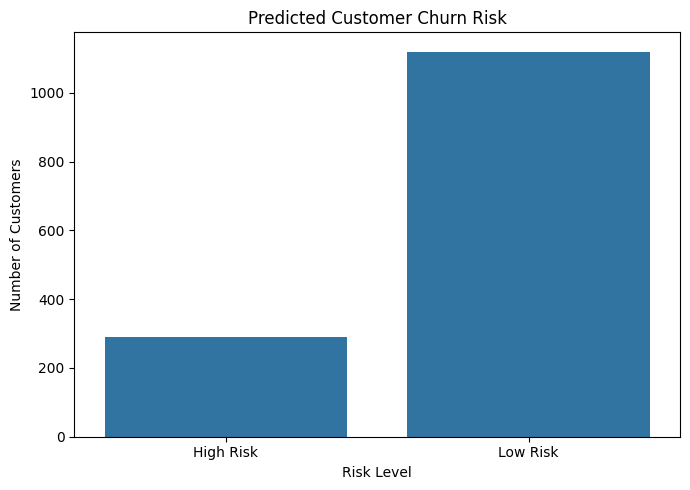

In [91]:
# ============================================================
# STEP 38: CHURN RISK DISTRIBUTION
# ============================================================

risk_distribution = (
    prediction_results["Churn_Prediction"]
    .value_counts()
    .reset_index()
)

risk_distribution.columns = [
    "RiskLevel",
    "CustomerCount"
]

print("\nCustomer Churn Risk Distribution:")
display(risk_distribution)


plt.figure(figsize=(7, 5))

sns.countplot(
    data=prediction_results,
    x="Churn_Prediction"
)

plt.title("Predicted Customer Churn Risk")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Step 38: Churn Risk Distribution

Customers are classified into two broad risk groups:

High Risk – Churn probability is at least 50%.
Low Risk – Churn probability is below 50%.

The distribution of these predicted risk categories is visualized.

This provides a practical business view of the predictive model's output.

In [92]:
# ============================================================
# STEP 39: FINAL BUSINESS INSIGHTS
# ============================================================

print("\n" + "=" * 70)
print("FINAL BUSINESS INSIGHTS")
print("=" * 70)

print("""
1. DESCRIPTIVE ANALYTICS
------------------------
Descriptive analytics identifies the overall customer base,
customer characteristics and the percentage of customers
who have already churned.

2. DIAGNOSTIC ANALYTICS
-----------------------
Diagnostic analytics identifies factors associated with churn,
including contract type, tenure, monthly charges, internet
service and payment method.

3. PREDICTIVE ANALYTICS
-----------------------
Machine learning models predict customers who are likely
to cancel their subscription.

4. BUSINESS ACTION
------------------
Customers predicted as high-risk can be targeted with
retention strategies such as:

- Personalized discounts
- Contract upgrade offers
- Better service plans
- Customer support intervention
- Loyalty rewards
- Customized pricing
- Long-term contract incentives

5. BUSINESS OBJECTIVE
---------------------
The ultimate goal is to identify high-risk customers early
and take preventive action before they leave the company.
""")


FINAL BUSINESS INSIGHTS

1. DESCRIPTIVE ANALYTICS
------------------------
Descriptive analytics identifies the overall customer base,
customer characteristics and the percentage of customers
who have already churned.

2. DIAGNOSTIC ANALYTICS
-----------------------
Diagnostic analytics identifies factors associated with churn,
including contract type, tenure, monthly charges, internet
service and payment method.

3. PREDICTIVE ANALYTICS
-----------------------
Machine learning models predict customers who are likely
to cancel their subscription.

4. BUSINESS ACTION
------------------
Customers predicted as high-risk can be targeted with
retention strategies such as:

- Personalized discounts
- Contract upgrade offers
- Better service plans
- Customer support intervention
- Loyalty rewards
- Customized pricing
- Long-term contract incentives

5. BUSINESS OBJECTIVE
---------------------
The ultimate goal is to identify high-risk customers early
and take preventive action before they le

# ============================================================
# STEP 39: FINAL BUSINESS INSIGHTS
# ============================================================

print("\n" + "=" * 70)
print("FINAL BUSINESS INSIGHTS")
print("=" * 70)

print("""
1. DESCRIPTIVE ANALYTICS
------------------------
Descriptive analytics identifies the overall customer base,
customer characteristics and the percentage of customers
who have already churned.

2. DIAGNOSTIC ANALYTICS
-----------------------
Diagnostic analytics identifies factors associated with churn,
including contract type, tenure, monthly charges, internet
service and payment method.

3. PREDICTIVE ANALYTICS
-----------------------
Machine learning models predict customers who are likely
to cancel their subscription.

4. BUSINESS ACTION
------------------
Customers predicted as high-risk can be targeted with
retention strategies such as:

- Personalized discounts
- Contract upgrade offers
- Better service plans
- Customer support intervention
- Loyalty rewards
- Customized pricing
- Long-term contract incentives

5. BUSINESS OBJECTIVE
---------------------
The ultimate goal is to identify high-risk customers early
and take preventive action before they leave the company.
""")

In [93]:
# ============================================================
# STEP 40: SAVE PREDICTIONS
# ============================================================

prediction_results.to_csv(
    "customer_churn_predictions.csv",
    index=False
)

print("\nPrediction file saved as:")
print("customer_churn_predictions.csv")


# ============================================================
# END OF ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("CUSTOMER CHURN ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 70)


Prediction file saved as:
customer_churn_predictions.csv

CUSTOMER CHURN ANALYSIS COMPLETED SUCCESSFULLY
